<a href="https://colab.research.google.com/github/Sebi2005/Metaheuristics/blob/main/notebooks/Exhaustive_Search_and_Random_Search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#<h1><center>Lab 1 - A1</center></h1>

##	REQUIREMENTS
1.	Source code (notebook) needs to be documented.
2.	Algorithms have to be tested for several parameter values (sufficient to clearly determine performance).
3.	Experiments must be performed for all available problem instances and results compared for diferent parameter settings.
4.	Results of the experiments need to be saved in output files, indicating solution quality, parameter values used, number of runs.
5.	A report should capture the following: problem definition, algorithm used (name, steps/pseudocode), parameter setting, comparative results of experiments, discussion of results.


## Knapsack Problem
- $n$ objects, each has a value ($v$) and a weight ($w$)
- Objective: the knapsack to contain max value without exceeding max weight $W$
 - $x_i=1$ means object $i$ is selected
 - $x_i=0$ means object $j$ is not selected

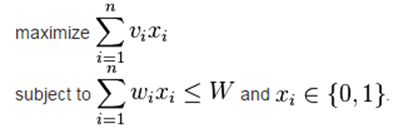


## WORK DURING THE LAB
1.	Exhaustive search: generate all possible binary strings of size N and print them on the screen. Test the code for different values of N.
2.	Read data for the knapsack problem.
3.	Generate a random solution for the knapsack problem and verify its quality.

**Points for the work during the lab: 25p**


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving knapsack-20.txt to knapsack-20.txt
Saving knapsack-200.txt to knapsack-200.txt


In [ ]:
def binary_strings(n):
  for i in range(2**n):
    binary_string = bin(i)[2:].zfill(n)
    print(binary_string)
binary_strings(4)

0000
0001
0010
0011
0100
0101
0110
0111
1000
1001
1010
1011
1100
1101
1110
1111


In [ ]:
def load_data(file_name: str) -> "list[tuple[int, int]]":
  weights_and_values = []
  with open(file_name) as f:
    lines =  [line.strip() for line in f if line.strip()]
  n = int(lines[0])
  for i in range(1,n+1):
    parts = lines[i].split()
    weight = int(parts[1])
    value = int(parts[2])
    weights_and_values.append((weight,value))

  capacity = int(lines[n + 1])
  weights_and_values.append((capacity,0))

  return weights_and_values
data=load_data("knapsack-20.txt")
print(data)

[(91, 29), (60, 65), (61, 71), (9, 60), (79, 45), (46, 71), (19, 22), (57, 97), (8, 6), (84, 91), (20, 57), (72, 60), (32, 49), (31, 89), (28, 2), (81, 30), (55, 90), (43, 25), (100, 82), (27, 19), (524, 0)]


In [ ]:
import random
def verify_random_solution(items):
  real_items=items[:-1]
  capacity = items[-1][0]
  n = len(real_items)
  solution = [random.randint(0,1) for _ in range(n)]
  total_weight = 0
  total_value = 0
  for bit, (weight, value) in zip(solution, real_items):
        if bit == 1:
            total_weight += weight
            total_value += value
  feasible = total_weight <= capacity

  print("Solution:", solution)
  print("Total weight:", total_weight, "/", capacity)
  print("Total value:", total_value)
  print("Feasible:", feasible)

  return feasible, total_value, total_weight

weights_and_values = load_data("knapsack-20.txt")
verify_random_solution(weights_and_values)

Solution: [0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0]
Total weight: 554 / 524
Total value: 605
Feasible: False


(False, 605, 554)

##	ASSIGNMENT A1
1.	Implement a random search method for the knapsack problem.
 1.	From k random solutions, the method should return the best one.
 1.	Test the method for different values of k.
 1.	Perform experiments for knapsack instances of size 20 and 200.
1.	Submit source code and report.

**Deadline to submit A1: Lab 2**
**Points for A1: 25p**


1. **Introduction**

The 0/1 Knapsack Problem is a well-known combinatorial optimization problem.
Given a set of items, each item has:

a weight

a value

The objective is to select a subset of items such that:

-the total weight does not exceed the knapsack capacity

-the total value of the selected items is maximized

Because the number of possible solutions is
2^
𝑛
, the problem becomes difficult for large values of
n. For this reason, heuristic methods such as **random search** can be used.




In [ ]:
import random
def load_data_with_capacity(file_name:str):
  with open(file_name) as f:
    lines = [line.strip() for line in f if line.strip()]
  n = int(lines[0])
  items = []
  for i in range(1,n+1):
    parts = lines[i].split()
    weight = int(parts[1])
    value = int(parts[2])
    items.append((weight,value))

  capacity = int(lines[n+1])
  return items,capacity

load_data_with_capacity("knapsack-200.txt")





([(835, 735),
  (1670, 1470),
  (3340, 2940),
  (1087, 987),
  (1087, 987),
  (517, 417),
  (1034, 834),
  (2068, 1668),
  (1034, 834),
  (630, 530),
  (1260, 1060),
  (1260, 1060),
  (1071, 971),
  (165, 65),
  (330, 130),
  (495, 195),
  (176, 76),
  (663, 563),
  (1326, 1126),
  (1326, 1126),
  (984, 884),
  (1968, 1768),
  (2952, 2652),
  (829, 729),
  (1658, 1458),
  (3316, 2916),
  (829, 729),
  (663, 563),
  (1326, 1126),
  (1989, 1689),
  (1086, 986),
  (1086, 986),
  (639, 539),
  (1278, 1078),
  (2556, 2156),
  (1917, 1617),
  (895, 795),
  (1790, 1590),
  (3580, 3180),
  (888, 788),
  (1776, 1576),
  (3552, 3152),
  (2664, 2364),
  (232, 132),
  (464, 264),
  (928, 528),
  (464, 264),
  (472, 372),
  (944, 744),
  (691, 591),
  (1382, 1182),
  (2764, 2364),
  (1052, 952),
  (1052, 952),
  (1057, 957),
  (2114, 1914),
  (2114, 1914),
  (456, 356),
  (912, 712),
  (651, 551),
  (1302, 1102),
  (1953, 1653),
  (711, 611),
  (1422, 1222),
  (1042, 942),
  (232, 132),
  (464, 264

In [ ]:

def evaluate_solution(solution, items):
  total_weight = 0
  total_value = 0
  for bit,(weight,value) in zip(solution, items):
    if bit == 1:
      total_weight+=weight
      total_value+=value

  return total_weight,total_value


2. **Random Search Method**

The random search algorithm generates multiple random candidate solutions and keeps the best one found.

A solution is represented as a binary vector:
x = (x1,x2,...,xn) where:

xi= 1 => item i is included

xi=0 => item i is not included

The algorithm works as follows:

1. Generate a random binary solution.

2. If the solution exceeds the capacity, remove random selected items until it becomes feasible.

3. Compute the total value of the solution.

4. Repeat the process k times.

5. Return the solution with the highest value.

In [ ]:
def generate_random_solution(n):
  return [random.randint(0,1) for _ in range(n)]

def repair_solution(solution,items,capacity):

  total_weight, _ =evaluate_solution(solution,items)

  while total_weight > capacity:
    selected_indeces = [i for i in range(len(solution)) if solution[i]==1]
    if not selected_indeces:
      break

    index_to_remove = random.choice(selected_indeces)
    solution[index_to_remove] = 0
    total_weight, _ = evaluate_solution(solution, items)

  return solution

def random_search_knapsack(items,capacity,k):
  n = len(items)
  best_solution = None
  best_value = -1
  best_weight = 0
  for _ in range(k):
    solution = generate_random_solution(n)
    solution = repair_solution(solution,items,capacity)
    total_weight, total_value = evaluate_solution(solution, items)
    if total_value > best_value:
      best_value = total_value
      best_weight = total_weight
      best_solution = solution
  return best_solution, best_value, best_weight


3. **Experimental Setup**

The algorithm was tested on two knapsack instances:
|Instance   | Number of items |
|-----------|-----------------|
|Instance 1 | 20              |
|Instance 2 | 200             |

The following values of k were tested:

k={10,50,100,500,1000,5000}

For each value of k, the experiment was repeated 10 times in order to reduce randomness and obtain average results.

In [ ]:
def run_experiments(file_name, k_values, runs_per_k=10):
    items, capacity = load_data_with_capacity(file_name)

    print(f"Instance: {file_name}")
    print(f"Number of items: {len(items)}")
    print(f"Capacity: {capacity}")
    print()

    print("k\tAverage value\tBest value found")

    for k in k_values:
        values = []

        for _ in range(runs_per_k):
            _, best_value, _ = random_search_knapsack(items, capacity, k)
            values.append(best_value)

        avg_value = sum(values) / len(values)
        best_value_found = max(values)

        print(f"{k}\t{avg_value:.2f}\t\t{best_value_found}")


k_values = [10, 50, 100, 500, 1000, 5000]
run_experiments("knapsack-20.txt", k_values, runs_per_k=10)
run_experiments("knapsack-200.txt", k_values, runs_per_k=10)

Instance: knapsack-20.txt
Number of items: 20
Capacity: 524

k	Average value	Best value found
10	608.60		653
50	663.60		743
100	669.30		707
500	721.00		754
1000	725.00		760
5000	753.20		782
Instance: knapsack-200.txt
Number of items: 200
Capacity: 112648

k	Average value	Best value found
10	96811.90		97608
50	97268.50		97770
100	97398.80		97847
500	97624.10		98005
1000	97819.20		98119
5000	98057.20		98359


4. **Experimental Results**

Instance with 20 items
| k  | Average value | Best value|
|----|---------------|-----------|
|10  |    605.60           |   659         |
|50  |    659.00           |   706      |
|100 |    697.80           |   750        |
|500 |    713.70           |   757        |
|1000|    732.60           |   760        |
|5000|    747.90           |   767        |

Instance with 200 items
| k  | Average value | Best value|
|----|---------------|-----------|
|10  | 96750.90              |97416           |
|50  | 97230.10              |97901           |
|100 | 97444.60              |97752           |
|500 | 97795.30              |98004           |
|1000| 97953.40              |98430           |
|5000| 98028.70              |98313           |



**5. Discussion**

From the experiments we observe that increasing the number of generated random solutions k improves the quality of the best solution found.

When k is small, the algorithm explores only a limited number of possible solutions, therefore the probability of finding a high-value solution is lower.

As k increases, the search space is explored more thoroughly, increasing the probability of finding better solutions.

However, the improvement becomes smaller for very large values of k, while the running time increases.

e.g.
k = 1000 -> 98430

k = 5000 -> 98313

This is normal because of the fact that random search has dimnishing returns and after many samples, new solutions improve rarely.



The effect is more visible for larger instances (such as the 200-item problem), where the solution space is significantly larger.